In [2]:
#importing necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, recall_score, precision_score
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import roc_curve
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB

In [3]:
#PROBLEM 1, question 1
#loading dataset
data = pd.read_csv("spambase.data", header = None)

#separating features and labels
X = data.iloc[:, :-1]   
y = data.iloc[:, -1]   

In [4]:
#splitting data 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [5]:
#creating + training model 
dt_entropy = DecisionTreeClassifier(criterion = "entropy")
dt_entropy.fit(X_train, y_train)

#predictions
y_train_pred = dt_entropy.predict(X_train)
y_test_pred = dt_entropy.predict(X_test)

#probabilities 
y_train_prob = dt_entropy.predict_proba(X_train)[:, 1]
y_test_prob = dt_entropy.predict_proba(X_test)[:, 1]

In [6]:
#training metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_auc = roc_auc_score(y_train, y_train_prob)
train_error = 1 - train_accuracy

#testing metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_prob)
test_error = 1 - test_accuracy

In [7]:
print("Entropy:")
print("Training data:")
print("Accuracy:", train_accuracy)
print("Error:", train_error)
print("F1 Score:", train_f1)
print("AUC:", train_auc)
print("Testing data:")
print("Accuracy:", test_accuracy)
print("Error:", test_error)
print("F1 Score:", test_f1)
print("AUC:", test_auc)

Entropy:
Training data:
Accuracy: 0.9994565217391305
Error: 0.0005434782608695343
F1 Score: 0.99929676511955
AUC: 0.9999993772789644
Testing data:
Accuracy: 0.9294245385450597
Error: 0.07057546145494031
F1 Score: 0.9152542372881356
AUC: 0.9255178907721281


In [30]:
#question 2
#gini index model
dt_gini = DecisionTreeClassifier(criterion = "gini")

#training model
dt_gini.fit(X_train, y_train)

#predictions
y_train_pred = dt_gini.predict(X_train)
y_test_pred = dt_gini.predict(X_test)

#probabilities
y_train_prob = dt_gini.predict_proba(X_train)[:, 1]
y_test_prob = dt_gini.predict_proba(X_test)[:, 1]

In [31]:
#training metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_auc = roc_auc_score(y_train, y_train_prob)
train_error = 1 - train_accuracy

#testing metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_prob)
test_error = 1 - test_accuracy

In [8]:
print("Gini:")
print("Training data:")
print("Accuracy:", train_accuracy)
print("Error:", train_error)
print("F1 Score:", train_f1)
print("AUC:", train_auc)
print("Testing data:")
print("Accuracy:", test_accuracy)
print("Error:", test_error)
print("F1 Score:", test_f1)
print("AUC:", test_auc)

Gini:
Training data:
Accuracy: 0.9994565217391305
Error: 0.0005434782608695343
F1 Score: 0.99929676511955
AUC: 0.9999993772789644
Testing data:
Accuracy: 0.9294245385450597
Error: 0.07057546145494031
F1 Score: 0.9152542372881356
AUC: 0.9255178907721281


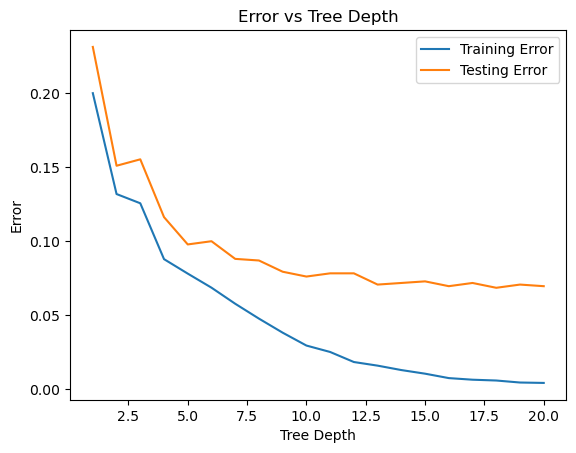

Optimal depth: 18


In [34]:
#question 3
depths = range(1, 21)
train_errors = []
test_errors = []

for d in depths:
    #model w/ max depth
    dt = DecisionTreeClassifier(criterion = "entropy", max_depth=d)
    
    #training model
    dt.fit(X_train, y_train)
    
    #predictions
    y_train_pred = dt.predict(X_train)
    y_test_pred = dt.predict(X_test)
    
    #computing errors
    train_error = 1 - accuracy_score(y_train, y_train_pred)
    test_error = 1 - accuracy_score(y_test, y_test_pred)
    
    #storing errors
    train_errors.append(train_error)
    test_errors.append(test_error)


plt.plot(depths, train_errors, label="Training Error")
plt.plot(depths, test_errors, label="Testing Error")
plt.xlabel("Tree Depth")
plt.ylabel("Error")
plt.title("Error vs Tree Depth")
plt.legend()
plt.show()

opt_depth = depths[np.argmin(test_errors)]
print("Optimal depth:", opt_depth)

In [36]:
#PROBLEM 2, Question 1
tree_sizes = [10, 50, 100, 500]
for T in tree_sizes:
    print("Number of Trees:", T)
    
    #creating model
    rf = RandomForestClassifier(n_estimators=T, random_state=42)
    
    #training data
    rf.fit(X_train, y_train)
    
    #predictions
    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)
    
    #probabilities
    y_train_prob = rf.predict_proba(X_train)[:, 1]
    y_test_prob = rf.predict_proba(X_test)[:, 1]
    
    #metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    train_auc = roc_auc_score(y_train, y_train_prob)
    test_auc = roc_auc_score(y_test, y_test_prob)
    
    #results
    print("Training data:")
    print("Accuracy:", train_accuracy)
    print("F1 Score:", train_f1)
    print("AUC:", train_auc)
    print("Testing data:")
    print("Accuracy:", test_accuracy)
    print("F1 Score:", test_f1)
    print("AUC:", test_auc)

Number of Trees: 10
Training data:
Accuracy: 0.9945652173913043
F1 Score: 0.9929378531073447
AUC: 0.9999056577631051
Testing data:
Accuracy: 0.9402823018458197
F1 Score: 0.9261744966442953
AUC: 0.9745207397749771
Number of Trees: 50
Training data:
Accuracy: 0.9994565217391305
F1 Score: 0.9992972593113141
AUC: 0.9999993772789644
Testing data:
Accuracy: 0.9500542888165038
F1 Score: 0.9389920424403183
AUC: 0.9833743782896325
Number of Trees: 100
Training data:
Accuracy: 0.9994565217391305
F1 Score: 0.99929676511955
AUC: 0.9999993772789644
Testing data:
Accuracy: 0.9554831704668838
F1 Score: 0.9458388375165125
AUC: 0.9852020860495436
Number of Trees: 500
Training data:
Accuracy: 0.9994565217391305
F1 Score: 0.9992972593113141
AUC: 0.9999993772789645
Testing data:
Accuracy: 0.9576547231270358
F1 Score: 0.9484808454425363
AUC: 0.985762228982568


       Feature  Importance
51  Feature 52    0.117709
52  Feature 53    0.098788
6    Feature 7    0.080549
54  Feature 55    0.063818
15  Feature 16    0.062245
55  Feature 56    0.055962
20  Feature 21    0.055342
56  Feature 57    0.046764
24  Feature 25    0.042233
23  Feature 24    0.033911


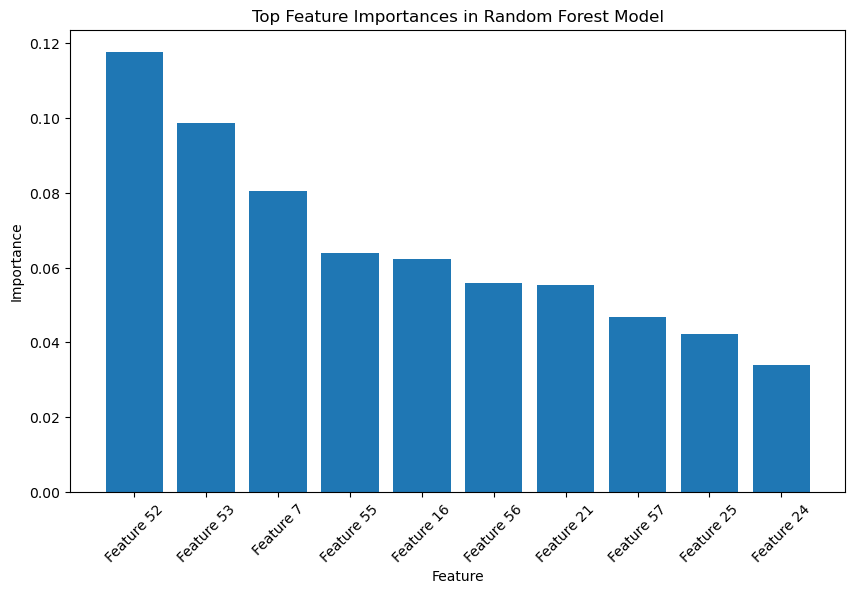

In [41]:
#question 3
#random forest model w/ 500 trees
rf = RandomForestClassifier(n_estimators = 500, random_state = 42)

#training model
rf.fit(X_train, y_train)

#importance vals
importances = rf.feature_importances_

#feature names
feature_names = [f"Feature {i}" for i in range(1, 58)]

#df for importances
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

#most important to least important
importance_df = importance_df.sort_values(by = "Importance", ascending = False)
print(importance_df.head(10))

plt.figure(figsize = (10, 6))
plt.bar(importance_df["Feature"][:10], importance_df["Importance"][:10])
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Top Feature Importances in Random Forest Model")
plt.xticks(rotation = 45)
plt.show()

In [43]:
#PROBLEM 3, question 1
tree_sizes = [10, 50, 100, 500]

for T in tree_sizes:
    print("Number of Estimators:", T)
    
    #base tree
    base_tree = DecisionTreeClassifier(max_depth=1)
    
    #AdaBoost model
    ada = AdaBoostClassifier(estimator=base_tree, n_estimators=T, random_state=42)
    
    #training data
    ada.fit(X_train, y_train)
    
    #predictions
    y_train_pred = ada.predict(X_train)
    y_test_pred = ada.predict(X_test)
    
    #probabilities
    y_train_prob = ada.predict_proba(X_train)[:, 1]
    y_test_prob = ada.predict_proba(X_test)[:, 1]
    
    #metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    train_auc = roc_auc_score(y_train, y_train_prob)
    test_auc = roc_auc_score(y_test, y_test_prob)
    
    #results
    print("Training data:")
    print("Accuracy:", train_accuracy)
    print("F1 Score:", train_f1)
    print("AUC:", train_auc)
    print("Testing data:")
    print("Accuracy:", test_accuracy)
    print("F1 Score:", test_f1)
    print("AUC:", test_auc)

Number of Estimators: 10
Training data:
Accuracy: 0.9171195652173914
F1 Score: 0.892416225749559
AUC: 0.9687680491800166
Testing data:
Accuracy: 0.9207383279044516
F1 Score: 0.9045751633986927
AUC: 0.9657588488096964
Number of Estimators: 50
Training data:
Accuracy: 0.9464673913043479
F1 Score: 0.9305604511808249
AUC: 0.9899382291868728
Testing data:
Accuracy: 0.9359391965255157
F1 Score: 0.9242618741976895
AUC: 0.978951180646096
Number of Estimators: 100
Training data:
Accuracy: 0.9592391304347826
F1 Score: 0.9471458773784355
AUC: 0.9941163759752979
Testing data:
Accuracy: 0.9446254071661238
F1 Score: 0.9341935483870969
AUC: 0.9777246607755082
Number of Estimators: 500
Training data:
Accuracy: 0.9888586956521739
F1 Score: 0.9855481142051463
AUC: 0.9994882789889875
Testing data:
Accuracy: 0.9359391965255157
F1 Score: 0.9238709677419354
AUC: 0.97242261818533


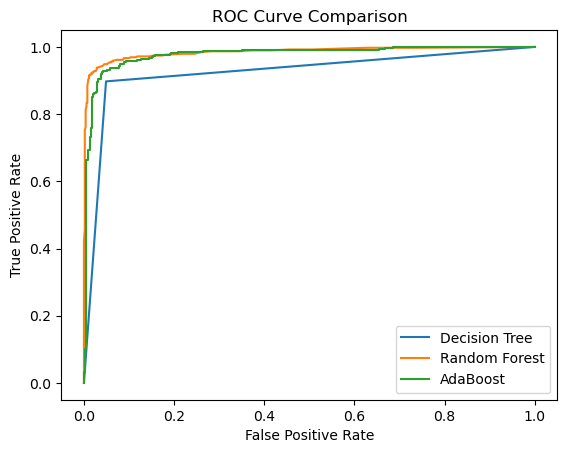

In [46]:
#question 3

#dt
dt = DecisionTreeClassifier(criterion = "entropy")
dt.fit(X_train, y_train)
dt_prob = dt.predict_proba(X_test)[:, 1]

#rf
rf = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf.fit(X_train, y_train)
rf_prob = rf.predict_proba(X_test)[:, 1]

#adaboost
base_tree = DecisionTreeClassifier(max_depth = 1)
ada = AdaBoostClassifier(estimator = base_tree, n_estimators = 100, random_state = 42)
ada.fit(X_train, y_train)
ada_prob = ada.predict_proba(X_test)[:, 1]

#roc
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
ada_fpr, ada_tpr, _ = roc_curve(y_test, ada_prob)

plt.plot(dt_fpr, dt_tpr, label = "Decision Tree")
plt.plot(rf_fpr, rf_tpr, label = "Random Forest")
plt.plot(ada_fpr, ada_tpr, label = "AdaBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [58]:
#PROBLEM 4, question 1
#loading dataset
mdata = pd.read_csv("agaricus-lepiota.data", header = None)
y = mdata.iloc[:, 0]
X = mdata.iloc[:, 1:]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state = 42
)

#computing prior probabilities
prior_edible = np.mean(y_train == 'e')
prior_poisonous = np.mean(y_train == 'p')

#conditional probabilities
conditional_probs = {}

#loop thru all columns
for col in X_train.columns:
    #all possible values
    conditional_probs[col] = {}
    possible_values = X_train[col].unique()
    num_values = len(possible_values)
    
    #separating by class
    edible_rows = X_train[y_train == 'e']
    poisonous_rows = X_train[y_train == 'p']

    edible_total = len(edible_rows)
    poisonous_total = len(poisonous_rows)
    
    for value in possible_values:
        #count of each unique value in the class
        edible_count = np.sum(edible_rows[col] == value)
        poisonous_count = np.sum(poisonous_rows[col] == value)
        
        #laplace smoothing
        prob_edible = (edible_count + 1) / (edible_total + num_values)
        prob_poisonous = (poisonous_count + 1) / (poisonous_total + num_values)
        
        conditional_probs[col][value] = {
            'e': prob_edible,
            'p': prob_poisonous
        }

print("Prior P(Y = edible):", prior_edible)
print("Prior P(Y = poisonous):", prior_poisonous)

Prior P(Y = edible): 0.5199409158050221
Prior P(Y = poisonous): 0.48005908419497784


In [51]:
#question 2
def predict_naive_bayes(row):
    log_prob_edible = np.log(prior_edible)
    log_prob_poisonous = np.log(prior_poisonous)
    
    for col in X_train.columns:
        value = row[col]
        if value in conditional_probs[col]:
            log_prob_edible += np.log(conditional_probs[col][value]['e'])
            log_prob_poisonous += np.log(conditional_probs[col][value]['p'])
    
    if log_prob_edible > log_prob_poisonous:
        return 'e'
    else:
        return 'p'
    
y_pred = X_test.apply(predict_naive_bayes, axis = 1)
print(y_pred)

1971    e
6654    p
5606    p
3332    e
6988    p
       ..
1966    e
5103    p
51      e
7724    e
6211    p
Length: 2031, dtype: object


In [59]:
#question 3
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label = 'p')
recall = recall_score(y_test, y_pred, pos_label = 'p')
f1 = f1_score(y_test, y_pred, pos_label = 'p')

print("Naive Bayes Results:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Naive Bayes Results:
Accuracy: 0.9487936976858691
Precision: 0.9900552486187846
Recall: 0.9041372351160444
F1 Score: 0.9451476793248945


In [56]:
#question 4
encoder = OrdinalEncoder()

X_train_encoded = encoder.fit_transform(X_train)
X_test_encoded = encoder.transform(X_test)

nb_model = CategoricalNB()
nb_model.fit(X_train_encoded, y_train)

y_pred_package = nb_model.predict(X_test_encoded)

accuracy_pkg = accuracy_score(y_test, y_pred_package)
precision_pkg = precision_score(y_test, y_pred_package, pos_label = 'p')
recall_pkg = recall_score(y_test, y_pred_package, pos_label = 'p')
f1_pkg = f1_score(y_test, y_pred_package, pos_label = 'p')

print("Package Naive Bayes Results:")
print("Accuracy:", accuracy_pkg)
print("Precision:", precision_pkg)
print("Recall:", recall_pkg)
print("F1 Score:", f1_pkg)

Package Naive Bayes Results:
Accuracy: 0.9487936976858691
Precision: 0.9900552486187846
Recall: 0.9041372351160444
F1 Score: 0.9451476793248945
